# BiLSTM 

In [8]:
# Bidirectional LSTM for Hinglish Offensive-Content Classification (Keras)

import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import fasttext

In [9]:
!git clone https://github.com/vardhman18/HinSafe.git /content/HINSAFE

fatal: destination path '/content/HINSAFE' already exists and is not an empty directory.


In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/HINSAFE")
sys.path.insert(0, str(PROJECT_ROOT))

print("Project exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())

Project exists: True
src exists: True


In [11]:
from src.preprocessing import basic_clean
from src.evaluate import evaluate_model

In [12]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [13]:
# File paths

TRAIN_PATH = PROJECT_ROOT / "datasets" / "processed" / "train_split.csv"
VAL_PATH = PROJECT_ROOT / "datasets" / "processed" / "val_split.csv"
TEST_PATH = PROJECT_ROOT / "datasets" / "processed" / "test_split.csv"

FASTTEXT_MODEL_PATH = PROJECT_ROOT / "embeddings" / "cc.hi.300.bin"

MODEL_PATH = PROJECT_ROOT / "saved_models" / "bilstm_keras.h5"
TOKENIZER_PATH = PROJECT_ROOT / "saved_models" / "bilstm_tokenizer.pkl"

RESULTS_PATH = PROJECT_ROOT / "results" / "model_comparison.csv"
CONFUSION_MATRIX_PATH = PROJECT_ROOT / "results" / "confusion_matrices" / "bilstm.png"
TRAINING_HISTORY_PATH = PROJECT_ROOT / "results" / "bilstm_training_history.png"

(PROJECT_ROOT / "saved_models").mkdir(exist_ok=True)
(PROJECT_ROOT / "results" / "confusion_matrices").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "embeddings").mkdir(exist_ok=True)

print("Train file exists:", TRAIN_PATH.exists())
print("Validation file exists:", VAL_PATH.exists())
print("Test file exists:", TEST_PATH.exists())

Train file exists: True
Validation file exists: True
Test file exists: True


In [14]:
# Model settings 
MAX_VOCAB_SIZE = 20000     # only keep the top 20,000 most frequent words
MAX_SEQUENCE_LENGTH = 50   # pad/truncate every comment to 50 tokens
EMBEDDING_DIM = 300        # FastText vectors are 300-dimensional
LSTM_UNITS = 128
BATCH_SIZE = 32
EPOCHS = 10

In [15]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [16]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [17]:
# Tokenization 
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

# convert text to sequences of integers 
train_sequences = tokenizer.texts_to_sequences(train_df["text"])
val_sequences = tokenizer.texts_to_sequences(val_df["text"])


In [18]:
# Padding sequences to ensure uniform length

X_train = pad_sequences(
    train_sequences, maxlen=MAX_SEQUENCE_LENGTH, 
    padding="post", truncating="post")
X_val = pad_sequences(
    val_sequences, maxlen=MAX_SEQUENCE_LENGTH, 
    padding="post", truncating="post")

y_train = train_df["label"].values
y_val = val_df["label"].values

In [19]:

print("Vocabulary size found:", len(tokenizer.word_index))
print("Training sequence shape:", X_train.shape)
print("Validation sequence shape:", X_val.shape)

Vocabulary size found: 11621
Training sequence shape: (4288, 50)
Validation sequence shape: (920, 50)


In [20]:
# See what one comment looks like after tokenizing and padding
print("\nExample - original text:", train_df["text"].iloc[0])
print("Example - as sequence:", train_sequences[0])
print("Example - padded:", X_train[0])


Example - original text: mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata chala ke tum b un ke sath the ye ha hidmat
Example - as sequence: [2806, 7, 4374, 9, 1051, 265, 152, 11, 24, 56, 87, 1052, 409, 5, 3, 1671, 35, 2078, 15, 195, 15, 162, 362, 7, 41, 127, 232, 7, 96, 98, 22, 87, 4375]
Example - padded: [2806    7 4374    9 1051  265  152   11   24   56   87 1052  409    5
    3 1671   35 2078   15  195   15  162  362    7   41  127  232    7
   96   98   22   87 4375    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [21]:
from pathlib import Path

EMBEDDINGS_DIR = Path("/content/HINSAFE/embeddings")
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
%cd /content/HINSAFE/embeddings

!wget -c https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.hi.300.bin.gz
!gunzip -f cc.hi.300.bin.gz

/content/HINSAFE/embeddings
--2026-09-30 19:01:36--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.hi.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.65.14.79, 18.65.14.94, 18.65.14.61, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.65.14.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4371554972 (4.1G) [application/octet-stream]
Saving to: ‘cc.hi.300.bin.gz’

cc.hi.300.bin.gz    100%[===================>]   4.07G  65.3MB/s    in 48s     

2026-09-30 19:02:24 (86.8 MB/s) - ‘cc.hi.300.bin.gz’ saved [4371554972/4371554972]



In [23]:
FASTTEXT_MODEL_PATH = Path(
    "/content/HINSAFE/embeddings/cc.hi.300.bin"
)

print("Exists:", FASTTEXT_MODEL_PATH.exists())

if not FASTTEXT_MODEL_PATH.exists():
    raise FileNotFoundError(str(FASTTEXT_MODEL_PATH))

print("Loading FastText model...")
ft_model = fasttext.load_model(str(FASTTEXT_MODEL_PATH))
print("FastText model loaded successfully!")

Exists: True
Loading FastText model...
FastText model loaded successfully!


In [24]:
#Load FastText embeddings and create embedding matrix

def build_embedding_matrix(word_index, fasttext_model, vocab_size, embedding_dim):
   
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    for word, index in word_index.items():
        if index >= vocab_size:
            continue
        embedding_matrix[index] = fasttext_model.get_word_vector(word)

    return embedding_matrix


vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

embedding_matrix = build_embedding_matrix(
    word_index=tokenizer.word_index,
    fasttext_model=ft_model,
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM
)


In [25]:
print("Vocabulary size :", vocab_size)
print("Embedding matrix shape:", embedding_matrix.shape)

Vocabulary size : 11622
Embedding matrix shape: (11622, 300)


In [26]:
#Build BiLSTM Model

from tensorflow.keras import Input

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,), dtype="int32"),
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.3),            # reduces overfitting
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")   # single output: probability of "offensive"
])

In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 300)        │     3,486,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,942,409 (15.04 MB)

 Trainable params: 455,809 (1.74 MB)

 Non-trainable params: 3,486,600 (13.30 MB)

In [29]:
# Train the model 

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)  # Stop training if validation loss doesn't improve for 3 epochs


In [30]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

print("Training complete")

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 181ms/step - accuracy: 0.6737 - loss: 0.5980 - val_accuracy: 0.7163 - val_loss: 0.5345
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.7402 - loss: 0.5167 - val_accuracy: 0.7348 - val_loss: 0.5039
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - accuracy: 0.7589 - loss: 0.4935 - val_accuracy: 0.7446 - val_loss: 0.5037
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.7656 - loss: 0.4743 - val_accuracy: 0.7565 - val_loss: 0.4916
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.7747 - loss: 0.4611 - val_accuracy: 0.7533 - val_loss: 0.4838
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.7766 - loss: 0.4571 - val_accuracy: 0.7554 - val_loss: 0.4871
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.7778 - loss: 0.4441 - val_accuracy: 0.7402 - val_loss: 0.4940
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.7829 - loss: 0

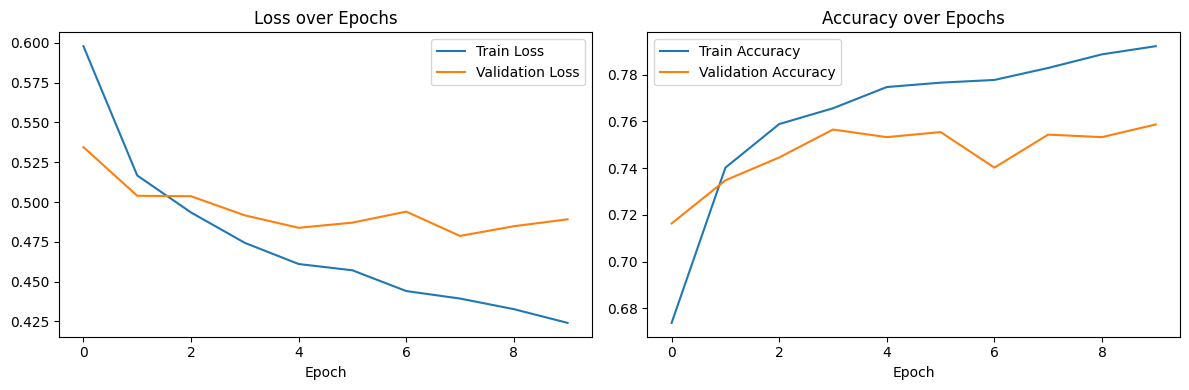

Training history plot saved to: /content/HINSAFE/results/bilstm_training_history.png


In [31]:
# Training history visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAINING_HISTORY_PATH, bbox_inches="tight")
plt.show()

print(f"Training history plot saved to: {TRAINING_HISTORY_PATH}")

In [32]:
# Validation and evaluation 
val_probabilities = model.predict(X_val)
val_predictions = (val_probabilities > 0.5).astype(int).flatten()

val_results = evaluate_model(
    y_true=y_val,
    y_pred=val_predictions,
    model_name="BiLSTM - Validation"
)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


In [33]:
import re 

sample_comments = [
    "tu mar ja",
    "thank you so much bhai",
    "kal milte hain, take care",
    "tu bekaar nahi hai"
]

cleaned_samples = [
    basic_clean(comment)
    for comment in sample_comments
]

sample_sequences = tokenizer.texts_to_sequences(cleaned_samples)

sample_padded = pad_sequences(
    sample_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

# Predict probabilities
sample_probabilities = model.predict(sample_padded, verbose=0)

# Display predictions
for comment, cleaned_comment, probability in zip(
    sample_comments,
    cleaned_samples,
    sample_probabilities
):
    probability = float(probability[0])
    label = "OFFENSIVE" if probability >= 0.5 else "NOT OFFENSIVE"

    print(
        f"{label:15s} | "
        f"Probability: {probability:.4f} | "
        f"{comment}"
    )

OFFENSIVE       | Probability: 0.9995 | tu mar ja
NOT OFFENSIVE   | Probability: 0.0553 | thank you so much bhai
NOT OFFENSIVE   | Probability: 0.1468 | kal milte hain, take care
OFFENSIVE       | Probability: 0.6029 | tu bekaar nahi hai


In [34]:
MODEL_PATH = PROJECT_ROOT / "saved_models" / "bilstm_keras.keras"

model.save(str(MODEL_PATH))

with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"Model saved to: {MODEL_PATH}")
print(f"Tokenizer saved to: {TOKENIZER_PATH}")

Model saved to: /content/HINSAFE/saved_models/bilstm_keras.keras
Tokenizer saved to: /content/HINSAFE/saved_models/bilstm_tokenizer.pkl


In [35]:
# Test set evaluation

test_sequences = tokenizer.texts_to_sequences(test_df["text"])
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH,
                       padding="post", truncating="post")
y_test = test_df["label"].values

test_probabilities = model.predict(X_test)
test_predictions = (test_probabilities > 0.5).astype(int).flatten()

test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="BiLSTM - Test"
)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step


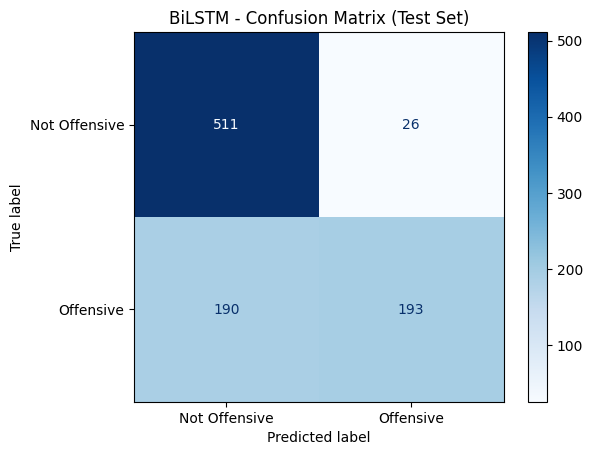

Confusion matrix saved to: /content/HINSAFE/results/confusion_matrices/bilstm.png


In [36]:
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot(cmap="Blues")
plt.title("BiLSTM - Confusion Matrix (Test Set)")
plt.savefig(CONFUSION_MATRIX_PATH, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {CONFUSION_MATRIX_PATH}")

In [37]:
# Save BiLSTM test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: /content/HINSAFE/results/model_comparison.csv


In [38]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.520000
1,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
2,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
3,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
4,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
5,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
6,BiLSTM - Test,0.765217,0.881279,0.503916,0.641196
